In [13]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt


In [ ]:
df = pd.read_csv('../data/scenario_6_marina_features_50ms.csv')


STEADY_THRESHOLD = 3000 #  5 second of buffer is healthy
DEPLETING_THRESHOLD = 700 # Below 0.4 seconds is a high risk of stalling

def assign_buffer_state(bh_ms):
    if bh_ms < DEPLETING_THRESHOLD:
        return 'Depleting'
    elif bh_ms > STEADY_THRESHOLD:
        return 'Steady'
    else:
        return 'Filling'

df['buffer_state'] = df['buffer_level_ms'].apply(assign_buffer_state)

all_features = [
    'throughput_kbps', 
    'packet_count', 
    'packet_size_mean',
    'jitter_ms'
]
X = df[all_features]
y = df['buffer_state']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

In [15]:
dt_baseline = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_baseline.fit(X_train, y_train)

print("--- Baseline Model (All Features) Evaluation ---")
y_pred_baseline = dt_baseline.predict(X_test)
print(classification_report(y_test, y_pred_baseline))

--- Baseline Model (All Features) Evaluation ---
              precision    recall  f1-score   support

   Depleting       0.73      0.17      0.27      2156
     Filling       0.57      0.95      0.71      2469

    accuracy                           0.58      4625
   macro avg       0.65      0.56      0.49      4625
weighted avg       0.64      0.58      0.50      4625




--- Feature Importances from Baseline Model ---
packet_size_mean    0.542201
jitter_ms           0.288994
throughput_kbps     0.138460
packet_count        0.030344
dtype: float64


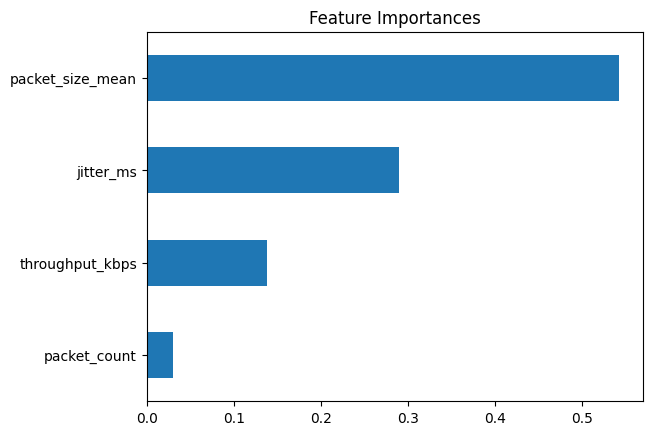

In [16]:
importances = pd.Series(dt_baseline.feature_importances_, index=all_features)
importances.sort_values(ascending=False, inplace=True)

print("\n--- Feature Importances from Baseline Model ---")
print(importances)

importances.sort_values().plot(kind='barh', title='Feature Importances')
plt.show()

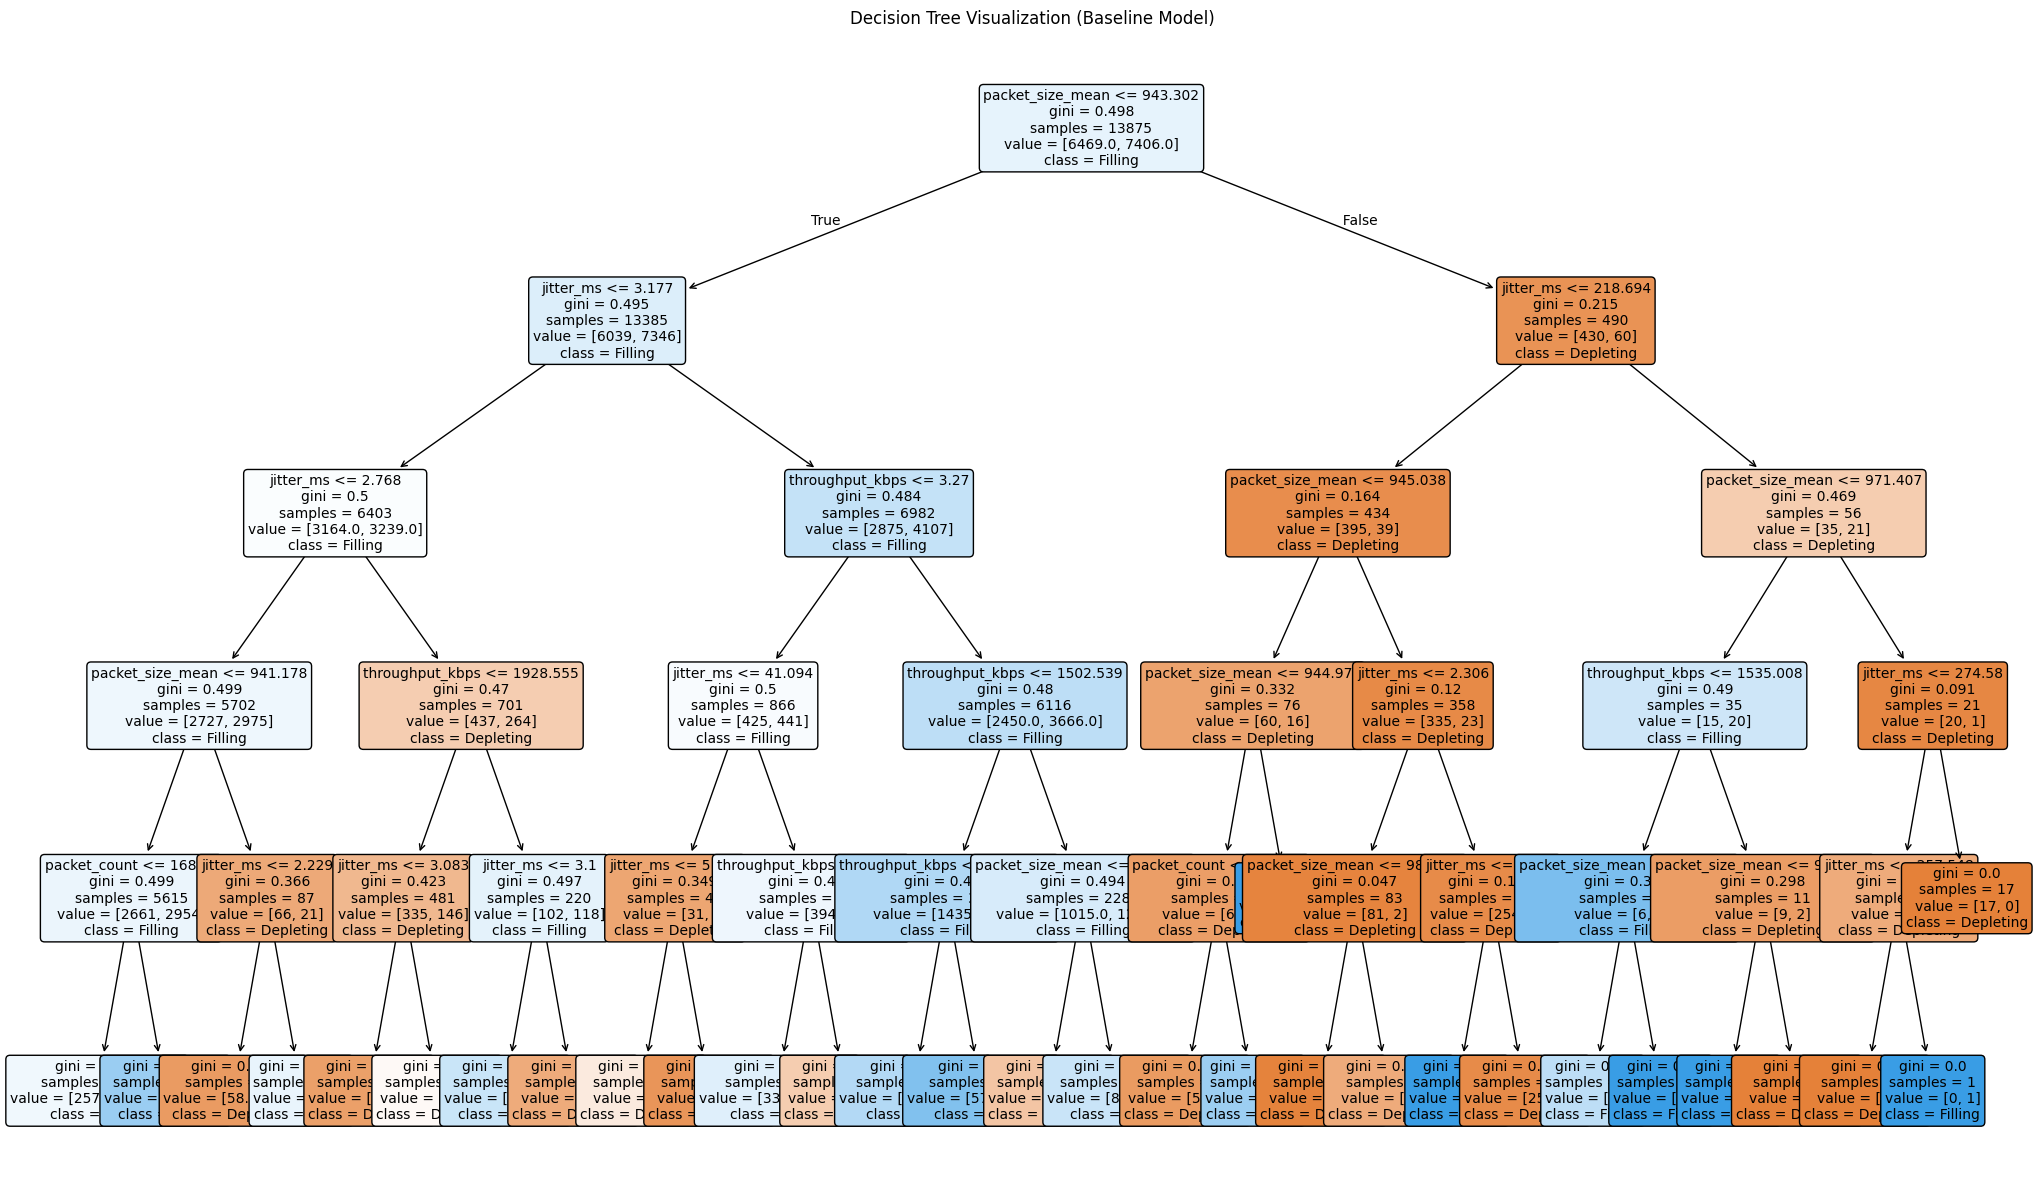

In [17]:
plt.figure(figsize=(25, 15))
plot_tree(dt_baseline, 
          feature_names=all_features, 
          class_names=dt_baseline.classes_, 
          filled=True, 
          rounded=True, 
          fontsize=10)
plt.title("Decision Tree Visualization (Baseline Model)")
plt.show()

In [18]:
#  different feature sets we want to test
feature_experiments = {
    "Throughput_Only": ['throughput_kbps'],
    "Packet_Size_Only": ['packet_size_mean'],
    "Timing_Only (Jitter)": ['jitter_ms'],
    "Timing_Only (IAT)": ['iat_mean_ms'], # Testing your IAT idea!
    "Throughput_and_Timing": ['throughput_kbps', 'jitter_ms'],
    "All_Features": ['throughput_kbps', 'packet_count', 'packet_size_mean', 'jitter_ms']
}

results = {}

print("\n\n--- Running Feature Set Experiments ---")

df['iat_mean_ms'] = pd.read_csv('../data/scenario_6_aggregated_1S.csv')['iat_mean_ms']

for name, features in feature_experiments.items():
    print(f"\n--- Testing: {name} ---")
    
    X_exp = df[features]
    y_exp = df['buffer_state']
    X_train_exp, X_test_exp, y_train_exp, y_test_exp = train_test_split(
        X_exp, y_exp, test_size=0.25, random_state=42, stratify=y_exp
    )
    
    model = DecisionTreeClassifier(max_depth=5, random_state=42)
    model.fit(X_train_exp, y_train_exp)
    
    y_pred_exp = model.predict(X_test_exp)
    report = classification_report(y_test_exp, y_pred_exp, output_dict=True)
    print(classification_report(y_test_exp, y_pred_exp))
    
    results[name] = report['Depleting']['recall']

print("\n\n--- Final Results: Recall for 'Depleting' State ---")
results_series = pd.Series(results)
results_series.sort_values(ascending=False, inplace=True)
print(results_series)



--- Running Feature Set Experiments ---

--- Testing: Throughput_Only ---
              precision    recall  f1-score   support

   Depleting       0.58      0.11      0.18      2156
     Filling       0.54      0.93      0.69      2469

    accuracy                           0.55      4625
   macro avg       0.56      0.52      0.43      4625
weighted avg       0.56      0.55      0.45      4625


--- Testing: Packet_Size_Only ---
              precision    recall  f1-score   support

   Depleting       0.70      0.12      0.20      2156
     Filling       0.55      0.96      0.70      2469

    accuracy                           0.56      4625
   macro avg       0.63      0.54      0.45      4625
weighted avg       0.62      0.56      0.47      4625


--- Testing: Timing_Only (Jitter) ---
              precision    recall  f1-score   support

   Depleting       0.54      0.30      0.39      2156
     Filling       0.56      0.78      0.65      2469

    accuracy                    